In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("Housing.csv")
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
data.shape

(545, 13)

In [7]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data = data.drop_duplicates()

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [15]:
data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [16]:
data.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [17]:
categorical_columns = data.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(data[col].unique())


mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']


In [18]:
for col in categorical_columns:
    print(f"\nValue Counts of {col}")
    print(data[col].value_counts())


Value Counts of mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

Value Counts of guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

Value Counts of basement
basement
no     354
yes    191
Name: count, dtype: int64

Value Counts of hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Value Counts of airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

Value Counts of prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

Value Counts of furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [19]:
for col in categorical_columns:
    print(f"\nValue Counts of {col}")
    print(data[col].value_counts())


Value Counts of mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

Value Counts of guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

Value Counts of basement
basement
no     354
yes    191
Name: count, dtype: int64

Value Counts of hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Value Counts of airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

Value Counts of prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

Value Counts of furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


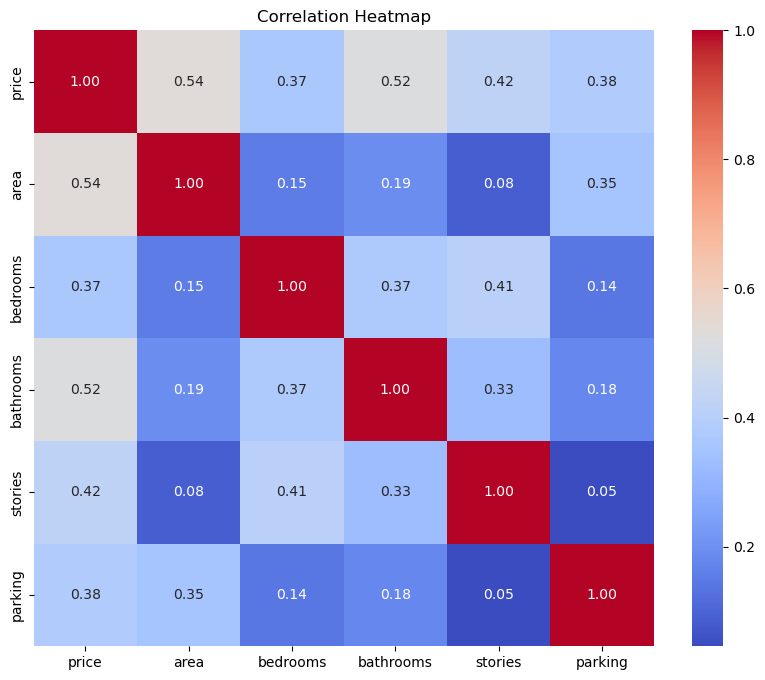

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

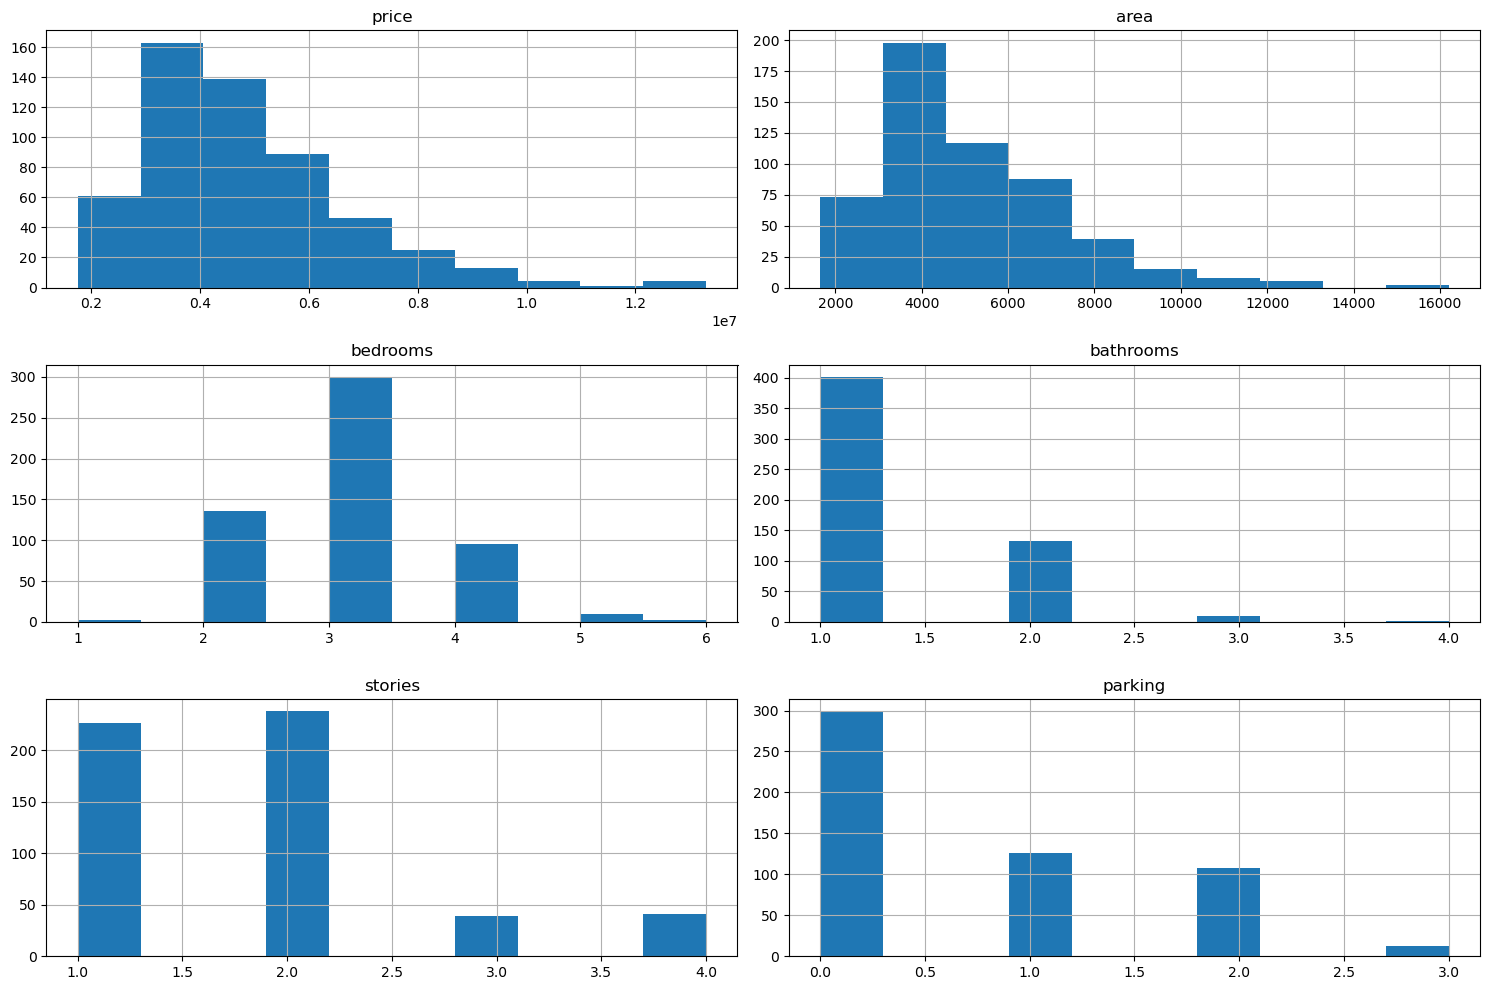

In [21]:
data.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

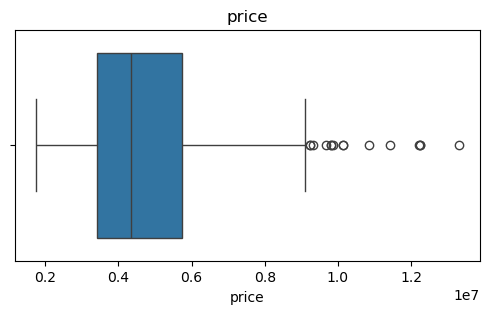

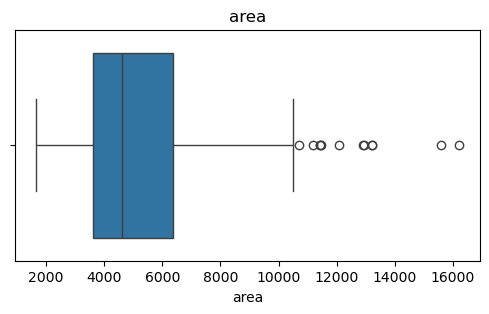

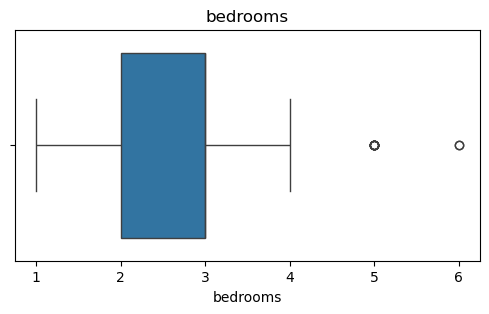

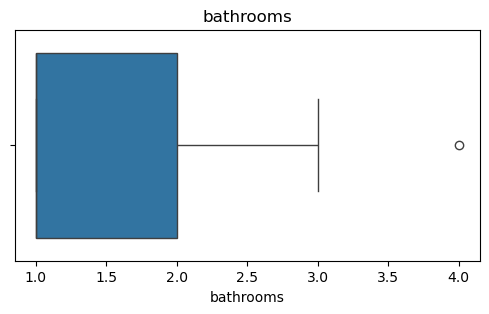

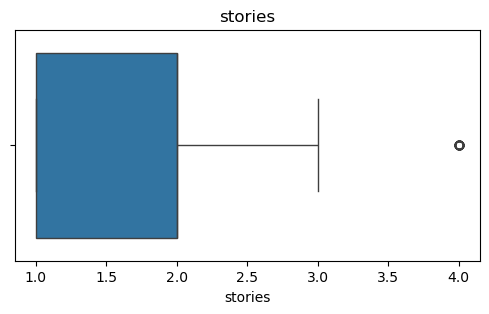

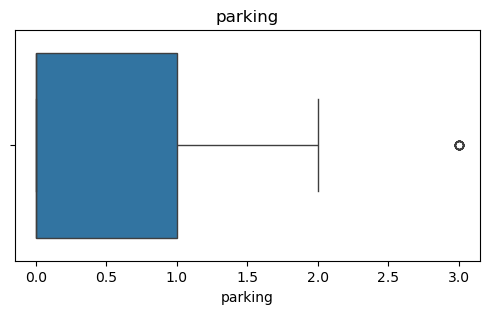

In [22]:
numerical_columns = data.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

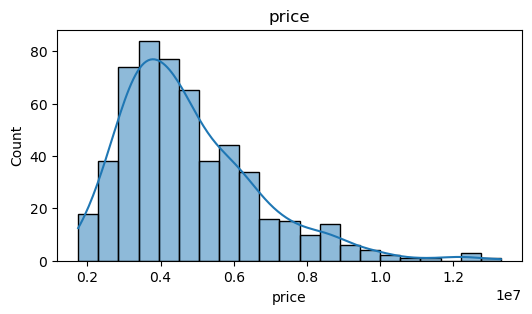

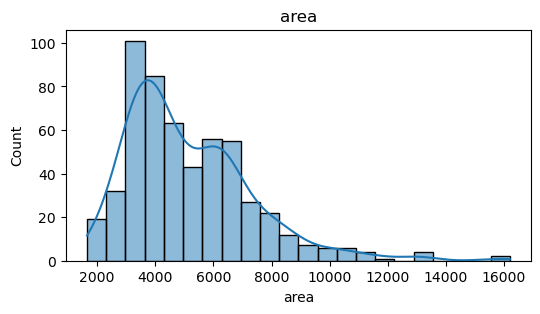

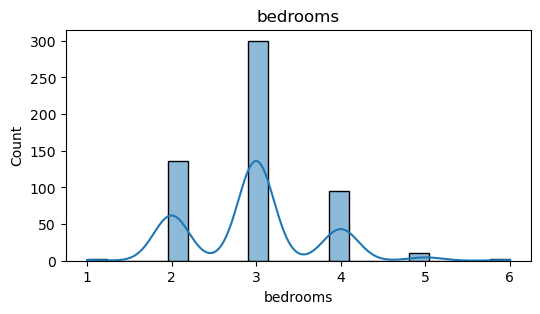

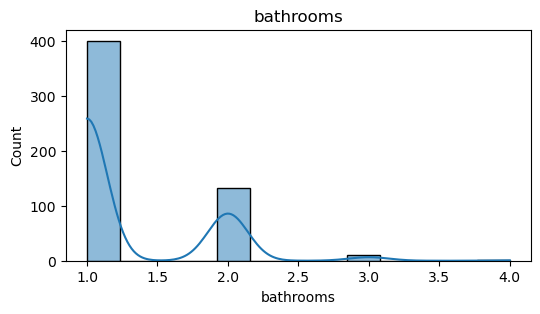

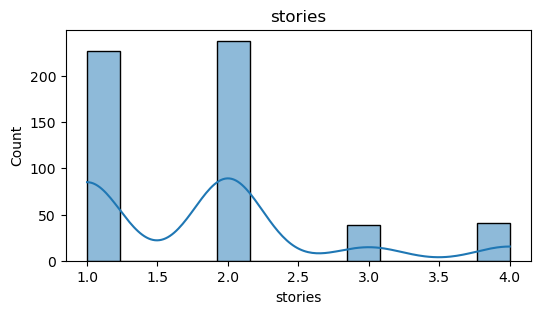

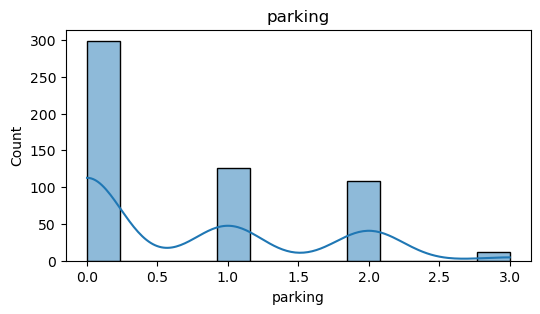

In [23]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

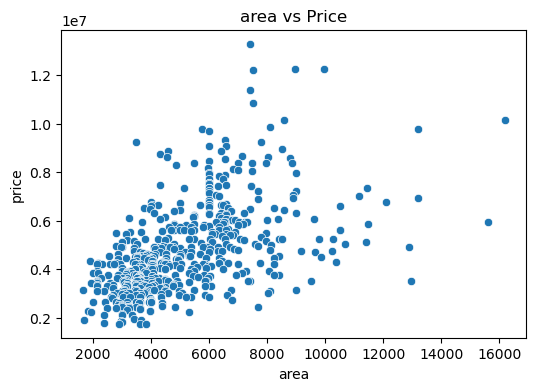

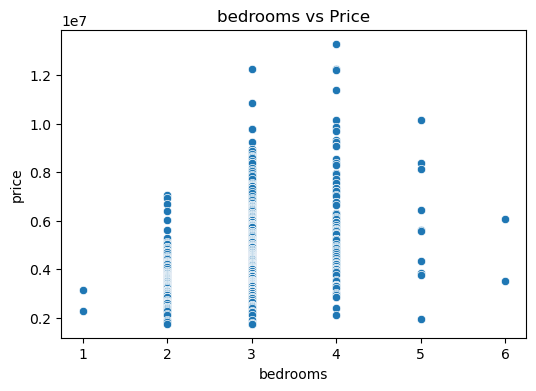

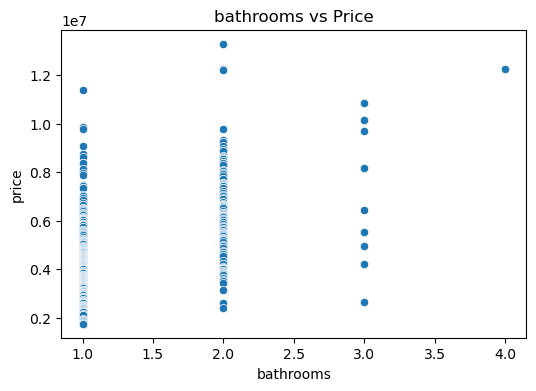

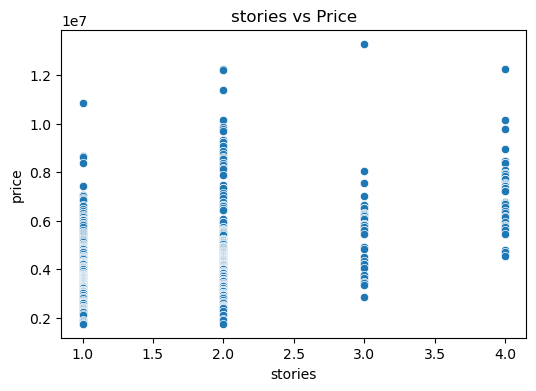

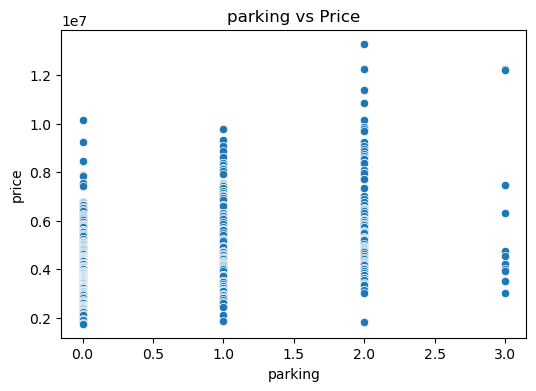

price: 0 outliers
area: 0 outliers
bedrooms: 0 outliers
bathrooms: 0 outliers
stories: 0 outliers
parking: 0 outliers


In [24]:
numeric_columns = data.select_dtypes(include=['int64','float64']).columns

for col in numeric_columns:
    if col != "price":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=data[col], y=data["price"])
        plt.title(f"{col} vs Price")
        plt.show()

for col in numerical_columns:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)
for col in numerical_columns:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

for col in numerical_columns:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

In [25]:
data.head()
categorical_columns = data.select_dtypes(include='object').columns
categorical_columns
le = LabelEncoder()

data["furnishingstatus"] = le.fit_transform(data["furnishingstatus"])
data


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9205000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,0
1,9205000,8960,4.0,3.5,3.5,yes,no,no,no,yes,2.5,no,0
2,9205000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,1
3,9205000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,2.5,yes,0
4,9205000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2.0,1.0,1.0,yes,no,yes,no,no,2.0,no,2
541,1767150,2400,3.0,1.0,1.0,no,no,no,no,no,0.0,no,1
542,1750000,3620,2.0,1.0,1.0,yes,no,no,no,no,0.0,no,2
543,1750000,2910,3.0,1.0,1.0,no,no,no,no,no,0.0,no,0


In [26]:
data.columns
data["total_rooms"] = data["bedrooms"] + data["bathrooms"]
data[["bedrooms", "bathrooms", "total_rooms"]].head()


,bedrooms,bathrooms,total_rooms
0,4.0,2.0,6.0
1,4.0,3.5,7.5
2,3.0,2.0,5.0
3,4.0,2.0,6.0
4,4.0,1.0,5.0


In [27]:
data["area_per_bedroom"] = data["area"] / data["bedrooms"]
data["area_per_bedroom"] = data["area"] / data["bedrooms"].replace(0, 1)
data["luxury_house"] = (
    (data["airconditioning"] == 1) &
    (data["mainroad"] == 1)
).astype(int)
data["total_facilities"] = (
    data["guestroom"] +
    data["basement"] +
    data["hotwaterheating"] +
    data["airconditioning"] +
    data["prefarea"]
)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_bedroom,luxury_house,total_facilities
0,9205000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,0,6.0,1855.0,0,nononoyesyes
1,9205000,8960,4.0,3.5,3.5,yes,no,no,no,yes,2.5,no,0,7.5,2240.0,0,nononoyesno
2,9205000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,1,5.0,3320.0,0,noyesnonoyes
3,9205000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,2.5,yes,0,6.0,1875.0,0,noyesnoyesyes
4,9205000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,0,5.0,1855.0,0,yesyesnoyesno


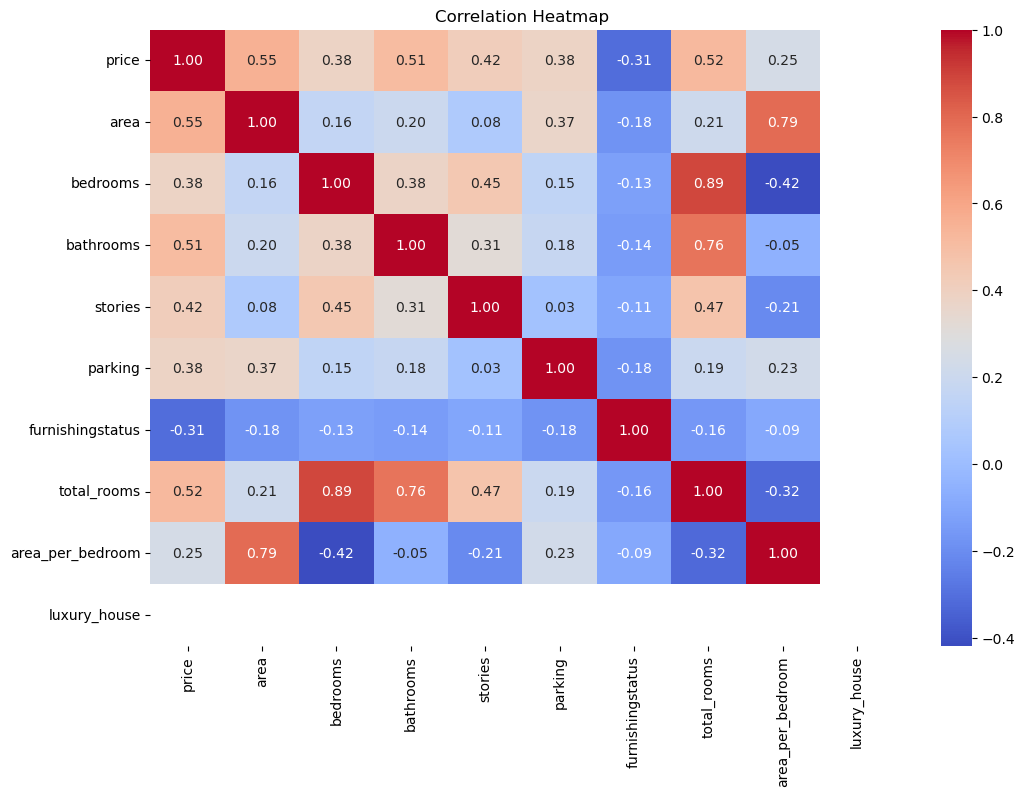

In [28]:
correlation = data.corr(numeric_only=True)

correlation["price"].sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Features Shape : (545, 16)
Target Shape : (545,)


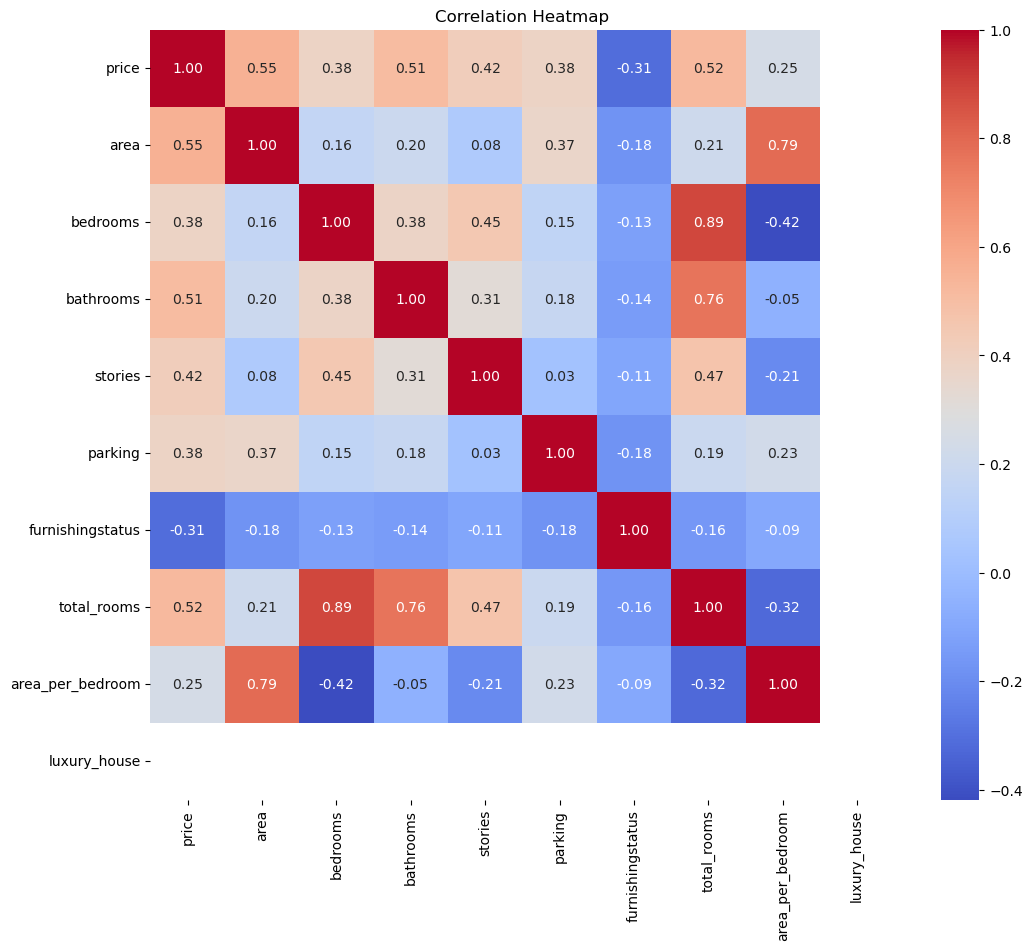

In [29]:
X = data.drop("price", axis=1)

y = data["price"]
X.head()
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
correlation["price"].sort_values(ascending=False)

price               1.000000
area                0.553876
total_rooms         0.520051
bathrooms           0.508576
stories             0.415874
bedrooms            0.381802
parking             0.380769
area_per_bedroom    0.245794
furnishingstatus   -0.307763
luxury_house             NaN
Name: price, dtype: float64

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

ValueError: could not convert string to float: 'yes'

In [ ]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.show()
print(X.head())
print(y.head())



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train Shape :", X_train.shape)
print("y_train Shape :", y_train.shape)
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)
print("Training Data Percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing Data Percentage:", round(len(X_test) / len(X) * 100, 2), "%")

In [ ]:
# 1. Reload fresh
data = pd.read_csv('Housing.csv')

# 2. Encode binary yes/no columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# 3. One-Hot Encode furnishingstatus
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

# 4. Confirm everything is numeric BEFORE splitting
print("Object columns remaining:", data.select_dtypes(include='object').columns.tolist())
# This must print an empty list [] before you continue

# 5. Split into train/test
from sklearn.model_selection import train_test_split
X = data.drop('price', axis=1)
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original X_train Shape :", X_train.shape)
print("Scaled X_train Shape   :", X_train_scaled.shape)
print("Original X_test Shape  :", X_test.shape)
print("Scaled X_test Shape    :", X_test_scaled.shape)

# 7. Convert scaled arrays back to DataFrames (keeps column names for readability)
scaled_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
scaled_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

scaled_train.head()

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully")

In [ ]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

In [ ]:
gradient_boost = GradientBoostingRegressor(
    random_state=42
)

gradient_boost.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgboost_model = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgboost_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor

In [ ]:
lightgbm_model = LGBMRegressor(
    random_state=42
)

lightgbm_model.fit(X_train, y_train)

print("LightGBM Model Trained Successfully")

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
catboost_model = CatBoostRegressor(
    verbose=0,
    random_state=42
)

catboost_model.fit(X_train, y_train)

print("CatBoost Model Trained Successfully")

In [ ]:
# Import Algorithms

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# XGBoost
from xgboost import XGBRegressor

# LightGBM
from lightgbm import LGBMRegressor

# CatBoost
from catboost import CatBoostRegressor


# ----------------------------
# Linear Regression
# ----------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# ----------------------------
# Decision Tree
# ----------------------------
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train, y_train)

# ----------------------------
# Random Forest
# ----------------------------
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest.fit(X_train, y_train)

# ----------------------------
# Gradient Boosting
# ----------------------------
gradient_boost = GradientBoostingRegressor(
    random_state=42
)
gradient_boost.fit(X_train, y_train)

# ----------------------------
# XGBoost
# ----------------------------
xgboost_model = XGBRegressor(
    random_state=42
)
xgboost_model.fit(X_train, y_train)

# ----------------------------
# LightGBM
# ----------------------------
lightgbm_model = LGBMRegressor(
    random_state=42
)
lightgbm_model.fit(X_train, y_train)

# ----------------------------
# CatBoost
# ----------------------------
catboost_model = CatBoostRegressor(
    verbose=0,
    random_state=42
)
catboost_model.fit(X_train, y_train)

print("All models trained successfully!")

In [ ]:
print(linear_model)
print(decision_tree)
print(random_forest)
print(gradient_boost)
print(xgboost_model)
print(lightgbm_model)
print(catboost_model)

In [ ]:
y_pred_linear = linear_model.predict(X_test_scaled)

print(y_pred_linear[:10])

In [ ]:
y_pred_rf = random_forest.predict(X_test)

print(y_pred_rf[:10])

In [ ]:
y_pred_xgb = xgboost_model.predict(X_test)

print(y_pred_xgb[:10])

In [ ]:
y_pred_xgb = xgboost_model.predict(X_test)

print(y_pred_xgb[:10])

In [ ]:
y_pred_cat = catboost_model.predict(X_test)

print(y_pred_cat[:10])

In [ ]:
import pandas as pd

comparison_linear = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_linear
})

comparison_linear.head(10)

In [ ]:
comparison_rf = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

comparison_rf.head(10)

In [ ]:
comparison_xgb = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_xgb
})

comparison_xgb.head(10)
print("Linear Regression :", y_pred_linear.shape)
print("Decision Tree     :", y_pred_dt.shape)
print("Random Forest     :", y_pred_rf.shape)
print("Gradient Boosting :", y_pred_gb.shape)
print("XGBoost           :", y_pred_xgb.shape)
print("LightGBM          :", y_pred_lgbm.shape)
print("CatBoost          :", y_pred_cat.shape)

In [ ]:
print("Linear Regression :", y_pred_linear.shape)
print("Decision Tree     :", y_pred_dt.shape)
print("Random Forest     :", y_pred_rf.shape)
print("Gradient Boosting :", y_pred_gb.shape)
print("XGBoost           :", y_pred_xgb.shape)
print("LightGBM          :", y_pred_lgbm.shape)
print("CatBoost          :", y_pred_cat.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Decision Tree
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train, y_train)

# Random Forest
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest.fit(X_train, y_train)

# Gradient Boosting
gradient_boost = GradientBoostingRegressor(random_state=42)
gradient_boost.fit(X_train, y_train)

# XGBoost
xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgboost_model.fit(X_train, y_train)

In [ ]:
# Linear Regression
y_pred_linear = linear_model.predict(X_test)

# Decision Tree
y_pred_dt = decision_tree.predict(X_test)

# Random Forest
y_pred_rf = random_forest.predict(X_test)

# Gradient Boosting
y_pred_gb = gradient_boost.predict(X_test)

# XGBoost
y_pred_xgb = xgboost_model.predict(X_test)

In [ ]:
print("Linear Prediction Shape :", y_pred_linear.shape)
print("Decision Tree Shape     :", y_pred_dt.shape)
print("Random Forest Shape     :", y_pred_rf.shape)
print("Gradient Boost Shape    :", y_pred_gb.shape)
print("XGBoost Shape           :", y_pred_xgb.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price (Random Forest)")

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd

In [32]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE": mape
    }

In [33]:
linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

linear_result

NameError: name 'y_test' is not defined

In [ ]:
dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

dt_result

In [ ]:
rf_result = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

rf_result

In [34]:
gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb
)

gb_result

NameError: name 'y_test' is not defined

In [35]:
results = pd.DataFrame([
    linear_result,
    dt_result,
    rf_result,
    gb_result,

])

results

NameError: name 'linear_result' is not defined

In [36]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

NameError: name 'results' is not defined

In [37]:
results.sort_values(
    by="RMSE",
    ascending=True
)

NameError: name 'results' is not defined

In [38]:
best_model = results.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]

print(best_model)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

NameError: name 'results' is not defined

In [39]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("Best Cross Validation Score:")
print(grid_search.best_score_)

NameError: name 'X_train' is not defined